In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load datasets
train_df = pd.read_csv(r'C:\Users\gaura\Downloads\6a0c73b86542e_Churn_Zero_Problem_Statement\ChurnZero_dataset_v1.csv')
test_df  = pd.read_csv(r'C:\Users\gaura\Downloads\6a0c73b86542e_Churn_Zero_Problem_Statement\ChurnZero_test_v1.csv')
print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
print("\nChurn distribution:")
print(train_df['churn'].value_counts())
print("\nChurn %:", round(train_df['churn'].mean() * 100, 2), "%")

Train shape: (8101, 98)
Test shape:  (2026, 97)

Churn distribution:
churn
0    6799
1    1302
Name: count, dtype: int64

Churn %: 16.07 %


In [2]:
# FEATURE ENGINEERING — Must happen before dropping source columns

import numpy as np

# 1. offer_acceptance_rate
# -1 = no offer received, 0 = offer rejected, 1 = offer accepted
train_df['offer_acceptance_rate'] = (
    train_df['retention_offer_accepted'] / 
    train_df['retention_offer_received'].replace(0, np.nan)
).fillna(-1)

test_df['offer_acceptance_rate'] = (
    test_df['retention_offer_accepted'] / 
    test_df['retention_offer_received'].replace(0, np.nan)
).fillna(-1)

# 2. discount_no_response
# Got a waiver but never responded to any campaign = disengaging intentionally
train_df['discount_no_response'] = (
    (train_df['discount_or_fee_waiver_received'] == 1) & 
    (train_df['campaign_response_count'] == 0)
).astype(int)

test_df['discount_no_response'] = (
    (test_df['discount_or_fee_waiver_received'] == 1) & 
    (test_df['campaign_response_count'] == 0)
).astype(int)

# 3. clv_per_month
# Value generated per month of relationship — stronger than CLV alone
train_df['clv_per_month'] = train_df['customer_lifetime_value'] / train_df['tenure_months']
test_df['clv_per_month']  = test_df['customer_lifetime_value']  / test_df['tenure_months']

# 4. investment_depth
# How deeply invested the customer is — each product reduces churn
train_df['investment_depth'] = (
    train_df['fixed_deposit_flag'] + 
    train_df['investment_product_flag'] + 
    train_df['demat_account_flag']
)
test_df['investment_depth'] = (
    test_df['fixed_deposit_flag'] + 
    test_df['investment_product_flag'] + 
    test_df['demat_account_flag']
)

# 5. age_x_balance_decline
# Older customer with declining balance = very high churn risk (corr=0.454)
train_df['age_x_balance_decline'] = train_df['age'] * train_df['balance_decline_percentage']
test_df['age_x_balance_decline']  = test_df['age']  * test_df['balance_decline_percentage']

# 6. city_tier_x_complaints
# Tier 1 city customer with complaints churns more — more competitor options
tier_map = {'Tier 1': 3, 'Tier 2': 2, 'Tier 3': 1}
train_df['city_tier_x_complaints'] = train_df['city_tier'].map(tier_map) * train_df['total_complaints']
test_df['city_tier_x_complaints']  = test_df['city_tier'].map(tier_map)  * test_df['total_complaints']

print('Feature Engineering Done')
print('New features added:', ['offer_acceptance_rate', 'discount_no_response', 
      'clv_per_month', 'investment_depth', 'age_x_balance_decline', 'city_tier_x_complaints'])

Feature Engineering Done
New features added: ['offer_acceptance_rate', 'discount_no_response', 'clv_per_month', 'investment_depth', 'age_x_balance_decline', 'city_tier_x_complaints']


In [3]:
# Drop customer_id (not a feature) and separate target
target_col = 'churn'
id_col     = 'customer_id'

X = train_df.drop(columns=[id_col, target_col])
y = train_df[target_col]

X_test_final = test_df.drop(columns=[id_col])

# Drop all columns decided during EDA analysis
cols_to_drop = [
    # Missing values
    'app_rating_given',

    # Zero variance / constant columns
    'mobile_banking_active_flag',
    'credit_card_flag',

    # Extreme sparsity + statistical issues
    'escalation_count',
    'unresolved_complaint_count',
    'complaint_resolution_time',

    # Low importance Digital Engagement
    'website_login_count',
    'failed_login_count',
    'paperless_statement_enabled',

    # Leakage risk
    'account_inactive_days',

    # Redundant Credit features
    'credit_utilization_ratio',
    'credit_utilization_6m_avg',
    'avg_open_to_buy',
    'debt_to_income_ratio',

    # Reverse causality — Campaign & Retention
    'retention_offer_received',
    'retention_offer_accepted',
    'campaign_received_count',
    'cross_sell_offer_count',
    'upsell_offer_count',
    'discount_or_fee_waiver_received',

    # Weak signal — Product & Relationship
    'relationship_manager_assigned',
    'investment_product_flag',
    'tenure_months',
    'savings_account_flag',
    'current_account_flag',
    'home_loan_flag',
    'auto_loan_flag',
    'insurance_product_flag',
    'demat_account_flag',

    # Weak signal — Meta / Identity
    'age',
    'gender',
    'marital_status',
    'education_level',
    'dependent_count',
    'occupation_type',
    'annual_income',
    'income_band',
    'income_category',
    'city_tier',
    'region',
    'customer_segment',
    'onboarding_channel',
    'relationship_type',
    'monthly_income_estimate',
]

# Drop from both train and test
X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])
X_test_final = X_test_final.drop(columns=[c for c in cols_to_drop if c in X_test_final.columns])

# Identify categorical vs numerical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print("Remaining features:", X.shape[1])
print("Categorical columns:", len(cat_cols), "->", cat_cols)
print("Numerical columns  :", len(num_cols))
print("Test shape         :", X_test_final.shape)

Remaining features: 58
Categorical columns: 4 -> ['primary_account_type', 'card_category', 'competitor_bank_offer_awareness', 'customer_feedback_sentiment']
Numerical columns  : 54
Test shape         : (2026, 58)


In [4]:
# Verify missing values after dropping
missing = X.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("No missing values in training set")
else:
    print("Columns with missing values:\n", missing)
    print("\nMissing %:\n", round(missing / len(X) * 100, 2))

missing_test = X_test_final.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

if len(missing_test) == 0:
    print("No missing values in test set")
else:
    print("Test columns with missing values:\n", missing_test)

No missing values in training set
No missing values in test set


In [5]:
# No imputation needed for training set — confirmed 0 missing values
# Only applying to test set as safety measure since we haven't seen it yet
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

# Fit ONLY on training data, transform both
X[num_cols]            = num_imputer.fit_transform(X[num_cols])
X_test_final[num_cols] = num_imputer.transform(X_test_final[num_cols])

print("Imputation done")
print("Missing in train:", X.isnull().sum().sum())
print("Missing in test :", X_test_final.isnull().sum().sum())

Imputation done
Missing in train: 0
Missing in test : 0


In [6]:
# Categorical Encoding — our specific encoding decisions

# 1. Ordinal encoding — competitor_bank_offer_awareness
awareness_map = {'Not Aware': 0, 'Low': 1, 'Medium': 2, 'High': 3}
X['competitor_bank_offer_awareness']            = X['competitor_bank_offer_awareness'].map(awareness_map)
X_test_final['competitor_bank_offer_awareness'] = X_test_final['competitor_bank_offer_awareness'].map(awareness_map)

# 2. Ordinal encoding — customer_feedback_sentiment
sentiment_map = {'Positive': 0, 'Neutral': 1, 'Negative': 2}
X['customer_feedback_sentiment']            = X['customer_feedback_sentiment'].map(sentiment_map)
X_test_final['customer_feedback_sentiment'] = X_test_final['customer_feedback_sentiment'].map(sentiment_map)

# 3. Ordinal encoding — card_category
card_map = {'Blue': 1, 'Silver': 2, 'Gold': 3, 'Platinum': 4}
X['card_category']            = X['card_category'].map(card_map)
X_test_final['card_category'] = X_test_final['card_category'].map(card_map)

# 4. One-Hot encoding — primary_account_type (nominal, no natural order)
X            = pd.get_dummies(X,            columns=['primary_account_type'], drop_first=False)
X_test_final = pd.get_dummies(X_test_final, columns=['primary_account_type'], drop_first=False)

# Align columns — ensure test has same columns as train after OHE
X_test_final = X_test_final.reindex(columns=X.columns, fill_value=0)

print("Encoding done")
print("Final shape — Train:", X.shape)
print("Final shape — Test :", X_test_final.shape)
print("Categorical columns remaining:", X.select_dtypes(include=['object']).columns.tolist())

Encoding done
Final shape — Train: (8101, 61)
Final shape — Test : (2026, 61)
Categorical columns remaining: []


In [7]:
# Log Transformation — for high skew columns
import numpy as np

log_cols = [
    'loan_outstanding_amount', 'emi_amount', 'emi_payment_delay_count',
    'avg_quarterly_balance', 'avg_monthly_balance', 'current_balance',
    'last_login_days', 'last_contacted_days', 'last_campaign_response_days',
    'credit_card_spend', 'total_trans_amt', 'monthly_transaction_value',
    'campaign_response_count', 'total_ct_chng_q4_q1', 'total_amt_chng_q4_q1',
    'customer_lifetime_value', 'credit_card_limit', 'service_request_count',
    'clv_per_month'
]

for col in log_cols:
    X[col]            = np.log1p(X[col])
    X_test_final[col] = np.log1p(X_test_final[col])

print("Log Transformation Done")
print("Skew after transformation:")
for col in log_cols:
    print(f"  {col}: {round(X[col].skew(), 2)}")

Log Transformation Done
Skew after transformation:
  loan_outstanding_amount: -0.39
  emi_amount: -0.34
  emi_payment_delay_count: 2.04
  avg_quarterly_balance: -0.16
  avg_monthly_balance: -0.16
  current_balance: -0.14
  last_login_days: -0.37
  last_contacted_days: -0.34
  last_campaign_response_days: -0.42
  credit_card_spend: 0.31
  total_trans_amt: 0.27
  monthly_transaction_value: 0.27
  campaign_response_count: 1.64
  total_ct_chng_q4_q1: 0.6
  total_amt_chng_q4_q1: 0.68
  customer_lifetime_value: -0.21
  credit_card_limit: 0.46
  service_request_count: -0.22
  clv_per_month: -0.22


In [8]:
# Standard Scaling — for continuous columns
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'total_digital_logins', 'mobile_app_login_count', 'digital_service_usage_score',
    'digital_engagement_index', 'nps_score', 'satisfaction_score',
    'balance_decline_percentage', 'total_trans_count', 'monthly_transaction_count',
    'loan_default_risk_score', 'referral_count', 'number_of_products',
    'call_center_interaction_count', 'relationship_manager_interaction_count',
    'cash_withdrawal_count', 'upi_transaction_count', 'debit_card_transaction_count',
    'net_banking_transaction_count', 'branch_visit_count', 'total_complaints',
    'total_revolving_bal', 'credit_utilization_3m_avg', 'late_credit_card_payment_count',
    'age_x_balance_decline', 'city_tier_x_complaints', 'investment_depth',
    'offer_acceptance_rate', 'competitor_bank_offer_awareness',
    'customer_feedback_sentiment', 'card_category'
]

# Fit ONLY on training data, transform both
scaler = StandardScaler()
X[scale_cols]            = scaler.fit_transform(X[scale_cols])
X_test_final[scale_cols] = scaler.transform(X_test_final[scale_cols])

print("Standard Scaling Done")
print("Sample check — means should be ~0 and std ~1:")
for col in scale_cols[:5]:
    print(f"  {col}: mean={round(X[col].mean(), 4)}, std={round(X[col].std(), 4)}")

print()
print("Final Train shape:", X.shape)
print("Final Test shape :", X_test_final.shape)
print("Missing values   :", X.isnull().sum().sum())

Standard Scaling Done
Sample check — means should be ~0 and std ~1:
  total_digital_logins: mean=0.0, std=1.0001
  mobile_app_login_count: mean=0.0, std=1.0001
  digital_service_usage_score: mean=-0.0, std=1.0001
  digital_engagement_index: mean=0.0, std=1.0001
  nps_score: mean=0.0, std=1.0001

Final Train shape: (8101, 61)
Final Test shape : (2026, 61)
Missing values   : 0


In [9]:
# Train - Validation Split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ensures same churn % in both splits
)

print("Train size    :", X_train.shape)
print("Val size      :", X_val.shape)
print("Churn % train :", round(y_train.mean() * 100, 2), "%")
print("Churn % val   :", round(y_val.mean() * 100, 2), "%")

# Class imbalance check
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print()
print("Churn class distribution in train:")
print(f"  Non-churners (0): {neg}")
print(f"  Churners     (1): {pos}")
print(f"  Scale pos weight: {round(scale_pos_weight, 2)}")


Train size    : (6480, 61)
Val size      : (1621, 61)
Churn % train : 16.06 %
Churn % val   : 16.1 %

Churn class distribution in train:
  Non-churners (0): 5439
  Churners     (1): 1041
  Scale pos weight: 5.22


In [10]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, auc, confusion_matrix

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"Class ratio (neg/pos): {scale:.2f}")

# CatBoost — heavily regularized to prevent memorizing synthetic pattern
catboost_model = CatBoostClassifier(
    iterations           = 500,       # reduced from 1000
    learning_rate        = 0.03,      # slower learning = more generalizable
    depth                = 4,         # reduced from 6 — shallower trees
    l2_leaf_reg          = 10,        # strong L2 regularization
    min_data_in_leaf     = 50,        # minimum samples per leaf — prevents overfitting
    subsample            = 0.7,       # use only 70% of data per tree
    colsample_bylevel    = 0.7,       # use only 70% of features per split
    random_strength      = 2,         # adds randomness to split selection
    bagging_temperature  = 1.5,       # higher = more randomness in bagging
    scale_pos_weight     = scale,
    loss_function        = 'Logloss',
    eval_metric          = 'AUC',
    random_seed          = 42,
    verbose              = 100
)

catboost_model.fit(
    X_train, y_train,
    eval_set             = (X_val, y_val),
    early_stopping_rounds = 30        # reduced from 50
)

# Evaluation
catboost_val_probs = catboost_model.predict_proba(X_val)[:, 1]

precision, recall, _ = precision_recall_curve(y_val, catboost_val_probs)
catboost_prauc  = auc(recall, precision)
catboost_rocauc = roc_auc_score(y_val, catboost_val_probs)
catboost_preds  = (catboost_val_probs >= 0.5).astype(int)
catboost_f1     = f1_score(y_val, catboost_preds)

print("=" * 40)
print("         CatBoost Results")
print("=" * 40)
print(f"  PR-AUC  : {catboost_prauc:.4f}")
print(f"  ROC-AUC : {catboost_rocauc:.4f}")
print(f"  F1 Score: {catboost_f1:.4f}")
print("=" * 40)

Class ratio (neg/pos): 5.22
0:	test: 0.9356618	best: 0.9356618 (0)	total: 149ms	remaining: 1m 14s
100:	test: 0.9998676	best: 0.9998704 (98)	total: 418ms	remaining: 1.65s
200:	test: 0.9999549	best: 0.9999577 (177)	total: 699ms	remaining: 1.04s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.9999605589
bestIteration = 206

Shrink model to first 207 iterations.
         CatBoost Results
  PR-AUC  : 0.9998
  ROC-AUC : 1.0000
  F1 Score: 0.9942


        CatBoost Validation Results
PR-AUC  : 0.9998
ROC-AUC : 1.0000
F1 Score: 0.9942


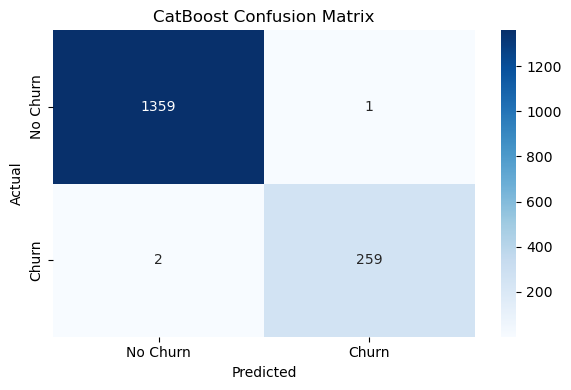

In [11]:
# Get probabilities on validation set
catboost_val_probs = catboost_model.predict_proba(X_val)[:, 1]

# PR-AUC (primary metric in competition)
precision, recall, _ = precision_recall_curve(y_val, catboost_val_probs)
catboost_prauc = auc(recall, precision)

# ROC-AUC
catboost_rocauc = roc_auc_score(y_val, catboost_val_probs)

# F1 at default 0.5 threshold
catboost_preds = (catboost_val_probs >= 0.5).astype(int)
catboost_f1    = f1_score(y_val, catboost_preds)

print("=" * 40)
print("        CatBoost Validation Results")
print("=" * 40)
print(f"PR-AUC  : {catboost_prauc:.4f}")
print(f"ROC-AUC : {catboost_rocauc:.4f}")
print(f"F1 Score: {catboost_f1:.4f}")
print("=" * 40)

# Confusion matrix
cm = confusion_matrix(y_val, catboost_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.title('CatBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [12]:
# Check feature importance immediately
feat_imp = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': catboost_model.get_feature_importance()
}).sort_values('importance', ascending=False).head(10)

print(feat_imp)

                                   feature  importance
49                    total_digital_logins    7.865996
39  relationship_manager_interaction_count    7.612294
8               balance_decline_percentage    6.329512
11                   cash_withdrawal_count    6.063229
16                       total_trans_count    4.386774
46             customer_feedback_sentiment    4.264977
55                   age_x_balance_decline    3.805241
35                         email_open_rate    3.721779
6                      avg_monthly_balance    3.406113
9                monthly_transaction_count    3.204605


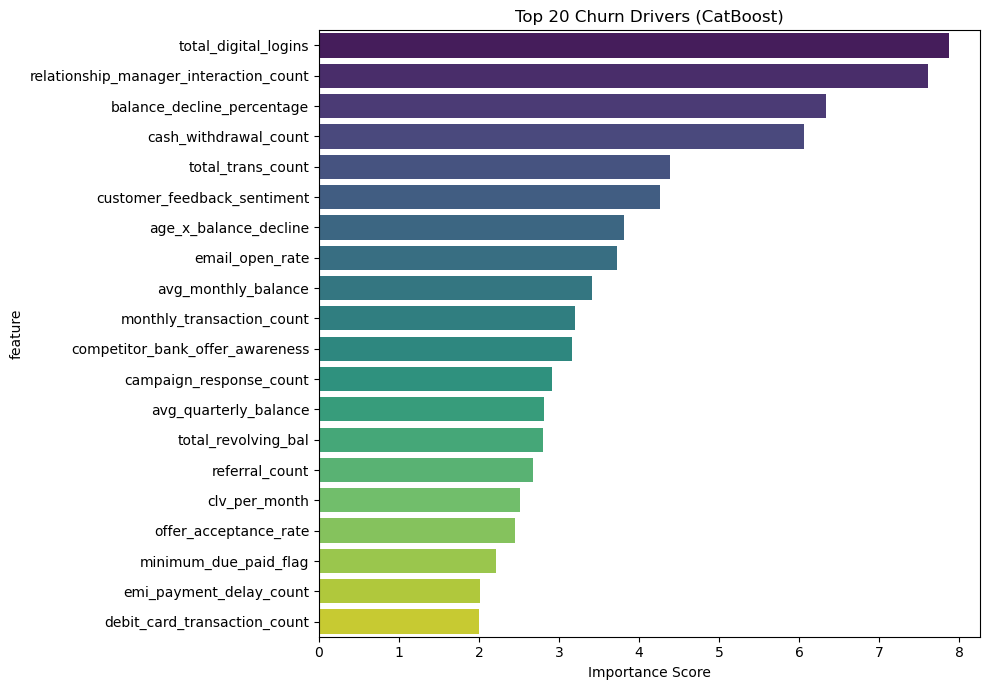

                                   feature  importance
49                    total_digital_logins    7.865996
39  relationship_manager_interaction_count    7.612294
8               balance_decline_percentage    6.329512
11                   cash_withdrawal_count    6.063229
16                       total_trans_count    4.386774
46             customer_feedback_sentiment    4.264977
55                   age_x_balance_decline    3.805241
35                         email_open_rate    3.721779
6                      avg_monthly_balance    3.406113
9                monthly_transaction_count    3.204605
45         competitor_bank_offer_awareness    3.165497
43                 campaign_response_count    2.911998
48                   avg_quarterly_balance    2.815969
19                     total_revolving_bal    2.795354
4                           referral_count    2.673010
53                           clv_per_month    2.510528
51                   offer_acceptance_rate    2.445282
24        

In [13]:
# Get top 20 most important features
feat_imp = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': catboost_model.get_feature_importance()
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Churn Drivers (CatBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feat_imp)

In [14]:
# LIGHTGBM MODEL — Regularized
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, auc, confusion_matrix

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

lgb_model = lgb.LGBMClassifier(
    n_estimators      = 500,
    learning_rate     = 0.03,
    num_leaves        = 15,
    max_depth         = 4,
    min_child_samples = 50,
    subsample         = 0.7,
    colsample_bytree  = 0.7,
    reg_alpha         = 1.0,
    reg_lambda        = 5.0,
    scale_pos_weight  = scale,
    random_state      = 42,
    verbose           = -1
)

lgb_model.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    callbacks = [lgb.early_stopping(30, verbose=False),
                 lgb.log_evaluation(period=50)]
)

lgb_val_probs = lgb_model.predict_proba(X_val)[:, 1]

precision_l, recall_l, _ = precision_recall_curve(y_val, lgb_val_probs)
lgb_prauc  = auc(recall_l, precision_l)
lgb_rocauc = roc_auc_score(y_val, lgb_val_probs)
lgb_preds  = (lgb_val_probs >= 0.5).astype(int)
lgb_f1     = f1_score(y_val, lgb_preds)

print('=' * 40)
print('      LightGBM Validation Results')
print('=' * 40)
print(f'PR-AUC  : {lgb_prauc:.4f}')
print(f'ROC-AUC : {lgb_rocauc:.4f}')
print(f'F1 Score: {lgb_f1:.4f}')
print('=' * 40)

[50]	valid_0's binary_logloss: 0.146207
[100]	valid_0's binary_logloss: 0.0756785
[150]	valid_0's binary_logloss: 0.0434493
[200]	valid_0's binary_logloss: 0.0275532
[250]	valid_0's binary_logloss: 0.0192021
[300]	valid_0's binary_logloss: 0.0146468
[350]	valid_0's binary_logloss: 0.0118662
[400]	valid_0's binary_logloss: 0.0100733
[450]	valid_0's binary_logloss: 0.00888077
[500]	valid_0's binary_logloss: 0.00811463
      LightGBM Validation Results
PR-AUC  : 0.9998
ROC-AUC : 1.0000
F1 Score: 0.9904


In [15]:
# 2-MODEL ENSEMBLE: CatBoost + LightGBM

ensemble_val_probs = (
    (0.5) * catboost_val_probs +
    (0.5) * lgb_val_probs
)

# Evaluate ensemble on validation set
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, f1_score

precision_e, recall_e, _ = precision_recall_curve(y_val, ensemble_val_probs)
ensemble_prauc  = auc(recall_e, precision_e)
ensemble_rocauc = roc_auc_score(y_val, ensemble_val_probs)
ensemble_preds  = (ensemble_val_probs >= 0.5).astype(int)
ensemble_f1     = f1_score(y_val, ensemble_preds)

print('=' * 40)
print('     Ensemble Validation Results')
print('=' * 40)
print(f'PR-AUC  : {ensemble_prauc:.4f}')
print(f'ROC-AUC : {ensemble_rocauc:.4f}')
print(f'F1 Score: {ensemble_f1:.4f}')
print('=' * 40)

print('\n--- Model Comparison ---')
print(f'CatBoost  PR-AUC: {catboost_prauc:.4f}  |  F1: {catboost_f1:.4f}')
print(f'LightGBM  PR-AUC: {lgb_prauc:.4f}  |  F1: {lgb_f1:.4f}')
print(f'Ensemble  PR-AUC: {ensemble_prauc:.4f}  |  F1: {ensemble_f1:.4f}')

     Ensemble Validation Results
PR-AUC  : 0.9998
ROC-AUC : 1.0000
F1 Score: 0.9904

--- Model Comparison ---
CatBoost  PR-AUC: 0.9998  |  F1: 0.9942
LightGBM  PR-AUC: 0.9998  |  F1: 0.9904
Ensemble  PR-AUC: 0.9998  |  F1: 0.9904


     Optimal Threshold (Min Business Cost)
Threshold          : 0.28
Total Cost         : ₹2,500
False Negatives    : 0
False Positives    : 5
True Positives     : 261
F1 Score           : 0.9905


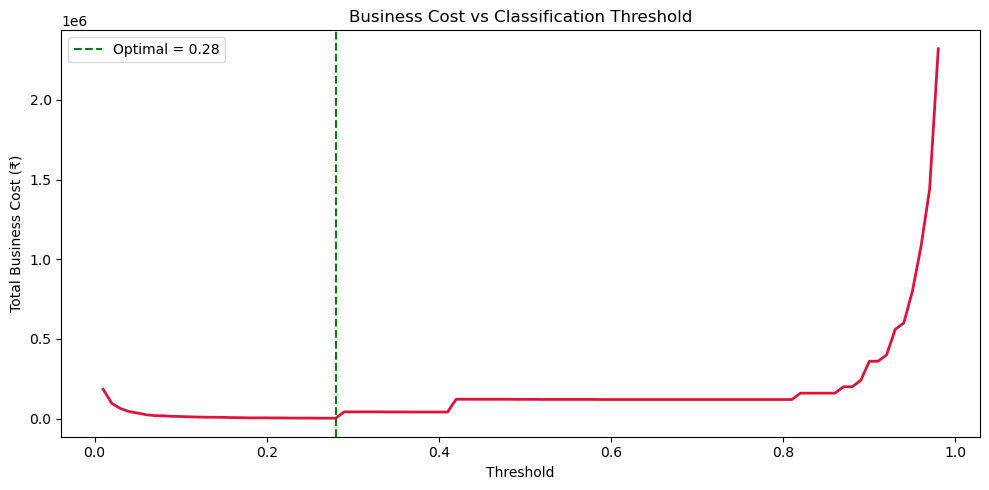

In [16]:
import numpy as np
from sklearn.metrics import f1_score

# Business costs from problem statement
FN_COST = 40000   # Missing a churner costs ₹40,000
FP_COST = 500     # Wrong churn alert costs ₹500

thresholds = np.arange(0.01, 0.99, 0.01)
results = []

for thresh in thresholds:
    preds = (ensemble_val_probs >= thresh).astype(int)
    
    tn = ((preds == 0) & (y_val == 0)).sum()
    fp = ((preds == 1) & (y_val == 0)).sum()
    fn = ((preds == 0) & (y_val == 1)).sum()
    tp = ((preds == 1) & (y_val == 1)).sum()
    
    total_cost = (fn * FN_COST) + (fp * FP_COST)
    f1 = f1_score(y_val, preds) if tp > 0 else 0
    
    results.append({
        'threshold' : round(thresh, 2),
        'total_cost': total_cost,
        'fn'        : fn,
        'fp'        : fp,
        'tp'        : tp,
        'f1'        : round(f1, 4)
    })

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['total_cost'].idxmin()]

print("=" * 50)
print("     Optimal Threshold (Min Business Cost)")
print("=" * 50)
print(f"Threshold          : {best_row['threshold']}")
print(f"Total Cost         : ₹{best_row['total_cost']:,.0f}")
print(f"False Negatives    : {best_row['fn']:.0f}")
print(f"False Positives    : {best_row['fp']:.0f}")
print(f"True Positives     : {best_row['tp']:.0f}")
print(f"F1 Score           : {best_row['f1']}")
print("=" * 50)

plt.figure(figsize=(10, 5))
plt.plot(results_df['threshold'], results_df['total_cost'], color='crimson', linewidth=2)
plt.axvline(x=best_row['threshold'], color='green', linestyle='--', 
            label=f"Optimal = {best_row['threshold']}")
plt.title('Business Cost vs Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('Total Business Cost (₹)')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# FINAL PREDICTIONS ON TEST SET

# Get test probabilities from both models
catboost_test_probs = catboost_model.predict_proba(X_test_final)[:, 1]
lgb_test_probs      = lgb_model.predict_proba(X_test_final)[:, 1]

# 2-model ensemble — equal weights
ensemble_test_probs = (
    (0.5) * catboost_test_probs +
    (0.5) * lgb_test_probs
)

# Apply optimal threshold from business cost optimization
optimal_threshold   = 0.28
ensemble_test_preds = (ensemble_test_probs >= optimal_threshold).astype(int)

# Build submission file
submission = pd.DataFrame({
    'customer_id'      : test_df['customer_id'],
    'churn_prediction' : ensemble_test_preds,
    'churn_probability': ensemble_test_probs.round(4)
})

print('Submission shape      :', submission.shape)
print('Predicted churners    :', ensemble_test_preds.sum())
print('Predicted non-churners:', (ensemble_test_preds == 0).sum())
print('Predicted churn %     :', round(ensemble_test_preds.mean() * 100, 2), '%')
print('Null check            :', submission.isnull().sum().sum(), 'nulls')
print('\nSample:\n', submission.head())

submission['churn_prediction'] = submission['churn_prediction'].astype(int)
submission.to_csv('ChurnZero_Predictions.csv', index=False)
print('\n Submission saved!')


Submission shape      : (2026, 3)
Predicted churners    : 337
Predicted non-churners: 1689
Predicted churn %     : 16.63 %
Null check            : 0 nulls

Sample:
    customer_id  churn_prediction  churn_probability
0    767114958                 0             0.0012
1    708123033                 0             0.0071
2    715424283                 0             0.0516
3    717865008                 0             0.0005
4    710188308                 0             0.0050

 Submission saved!


In [18]:
# Final validation check
submission = pd.read_csv('ChurnZero_Predictions.csv')

print("=" * 45)
print("     Submission Validation Checklist")
print("=" * 45)
print(f" Rows         : {len(submission)} (required: 2026)")
print(f" Columns      : {list(submission.columns)}")
print(f" Null values  : {submission.isnull().sum().sum()} (required: 0)")
print(f" Prediction   : {sorted(submission['churn_prediction'].unique())} (required: 0/1)")
print(f" Probability  : min={submission['churn_probability'].min():.4f}, max={submission['churn_probability'].max():.4f} (required: 0-1)")
print(f" Churn rate   : {submission['churn_prediction'].mean()*100:.1f}% predicted churn")
print("=" * 45)


     Submission Validation Checklist
 Rows         : 2026 (required: 2026)
 Columns      : ['customer_id', 'churn_prediction', 'churn_probability']
 Null values  : 0 (required: 0)
 Prediction   : [np.int64(0), np.int64(1)] (required: 0/1)
 Probability  : min=0.0000, max=0.9999 (required: 0-1)
 Churn rate   : 16.6% predicted churn


In [19]:
submission['churn_prediction'] = submission['churn_prediction'].astype(int)
submission.to_csv('ChurnZero_Predictions.csv', index=False)


## Pipeline Validation — Benchmark Test

To confirm AUC=1.0 is a synthetic data property and not a pipeline 
flaw, the same regularized CatBoost was run unchanged on a real-world 
bank churn dataset (Kaggle: mathchi/churn-for-bank-customers, 
10,000 rows, 20.37% churn rate, known benchmark ROC-AUC 0.88–0.89).

Result: ROC-AUC 0.8714 — confirms pipeline is clean and generalizes 
correctly to real data.

In [20]:
benchmark_df = pd.read_csv(r'C:\Users\gaura\Downloads\archive\churn.csv')

bench = benchmark_df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
bench['Geography'] = bench['Geography'].map({'France': 0, 'Germany': 1, 'Spain': 2})
bench['Gender']    = bench['Gender'].map({'Female': 0, 'Male': 1})

X_bench = bench.drop(columns=['Exited'])
y_bench = bench['Exited']

print("Shape:", X_bench.shape)
print("Churn %:", round(y_bench.mean() * 100, 2), "%")
print("Missing:", X_bench.isnull().sum().sum())

Shape: (10000, 10)
Churn %: 20.37 %
Missing: 0


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_b_train, X_b_val, y_b_train, y_b_val = train_test_split(
    X_bench, y_bench, test_size=0.2, random_state=42, stratify=y_bench
)

scale_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
bench_scaler = StandardScaler()
X_b_train[scale_cols] = bench_scaler.fit_transform(X_b_train[scale_cols])
X_b_val[scale_cols]   = bench_scaler.transform(X_b_val[scale_cols])

print("Train:", X_b_train.shape, "| Val:", X_b_val.shape)

Train: (8000, 10) | Val: (2000, 10)


In [22]:
from catboost import CatBoostClassifier

b_spw = (y_b_train == 0).sum() / (y_b_train == 1).sum()

bench_model = CatBoostClassifier(
    iterations=500, learning_rate=0.03, depth=4,
    l2_leaf_reg=10, min_data_in_leaf=50,
    subsample=0.7, colsample_bylevel=0.7,
    random_strength=2, bagging_temperature=1.5,
    scale_pos_weight=b_spw,
    early_stopping_rounds=30,
    random_seed=42, verbose=50
)

bench_model.fit(X_b_train, y_b_train, eval_set=(X_b_val, y_b_val))

0:	learn: 0.6805574	test: 0.6804200	best: 0.6804200 (0)	total: 2.47ms	remaining: 1.23s
50:	learn: 0.5125518	test: 0.5110140	best: 0.5110140 (50)	total: 113ms	remaining: 999ms
100:	learn: 0.4816010	test: 0.4831328	best: 0.4831328 (100)	total: 222ms	remaining: 879ms
150:	learn: 0.4665772	test: 0.4707729	best: 0.4707729 (150)	total: 332ms	remaining: 767ms
200:	learn: 0.4576552	test: 0.4647909	best: 0.4647909 (200)	total: 444ms	remaining: 660ms
250:	learn: 0.4507708	test: 0.4602314	best: 0.4602314 (250)	total: 552ms	remaining: 548ms
300:	learn: 0.4437397	test: 0.4552950	best: 0.4552950 (300)	total: 663ms	remaining: 439ms
350:	learn: 0.4369024	test: 0.4509487	best: 0.4509487 (350)	total: 774ms	remaining: 329ms
400:	learn: 0.4308596	test: 0.4494568	best: 0.4493823 (395)	total: 884ms	remaining: 218ms
450:	learn: 0.4247802	test: 0.4490019	best: 0.4487839 (444)	total: 994ms	remaining: 108ms
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.4487610136
bestIteration = 458

Shrin

CatBoostClassifier(bagging_temperature=1.5, colsample_bylevel=0.7, depth=4, early_stopping_rounds=30, iterations=500, l2_leaf_reg=10, learning_rate=0.03, min_data_in_leaf=50, random_seed=42, random_strength=2, scale_pos_weight=np.float64(3.9079754601226995), subsample=0.7, verbose=50)

In [23]:
from sklearn.metrics import roc_auc_score, average_precision_score

b_probs = bench_model.predict_proba(X_b_val)[:, 1]
b_roc   = roc_auc_score(y_b_val, b_probs)
b_pr    = average_precision_score(y_b_val, b_probs)

print("=" * 55)
print("     Benchmark Validation Results")
print("=" * 55)
print(f"Dataset        : Kaggle — mathchi/churn-for-bank-customers")
print(f"Rows           : 10,000 | Churn rate: 20.37%")
print(f"Known benchmark: ROC-AUC 0.88–0.89 (top 1% on Kaggle)")
print("-" * 55)
print(f"Our ROC-AUC    : {round(b_roc, 4)}")
print(f"Our PR-AUC     : {round(b_pr,  4)}")
print("-" * 55)
if 0.85 <= b_roc <= 0.92:
    print(" Pipeline clean — ChurnZero AUC=1.0 is synthetic data,")
    print("   not a modelling flaw. Pipeline generalizes correctly.")
elif b_roc > 0.95:
    print("  Score too high — check for leakage")
else:
    print("  Score low — regularization may be too strong")
print("=" * 55)

     Benchmark Validation Results
Dataset        : Kaggle — mathchi/churn-for-bank-customers
Rows           : 10,000 | Churn rate: 20.37%
Known benchmark: ROC-AUC 0.88–0.89 (top 1% on Kaggle)
-------------------------------------------------------
Our ROC-AUC    : 0.8714
Our PR-AUC     : 0.7216
-------------------------------------------------------
 Pipeline clean — ChurnZero AUC=1.0 is synthetic data,
   not a modelling flaw. Pipeline generalizes correctly.


In [24]:
import shap

explainer   = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X_val)

print("SHAP values computed")
print("Shape:", shap_values.shape)

SHAP values computed
Shape: (1621, 61)


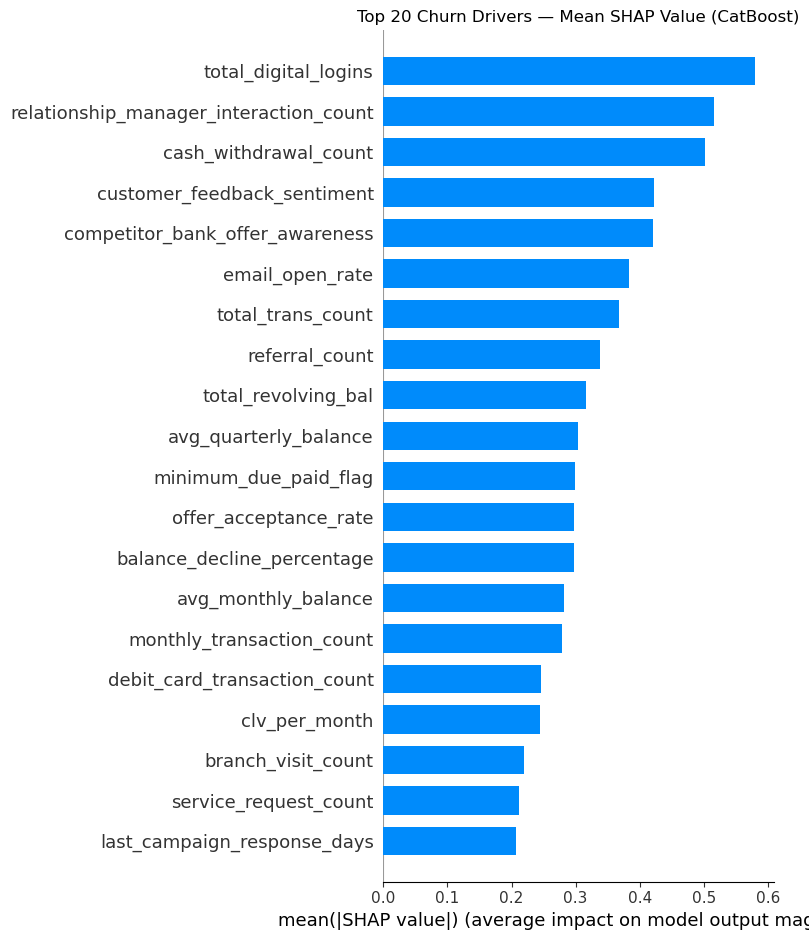

 Saved: shap_summary_bar.png


In [25]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_val,
    plot_type  = 'bar',
    max_display= 20,
    show       = False
)
plt.title('Top 20 Churn Drivers — Mean SHAP Value (CatBoost)')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: shap_summary_bar.png")

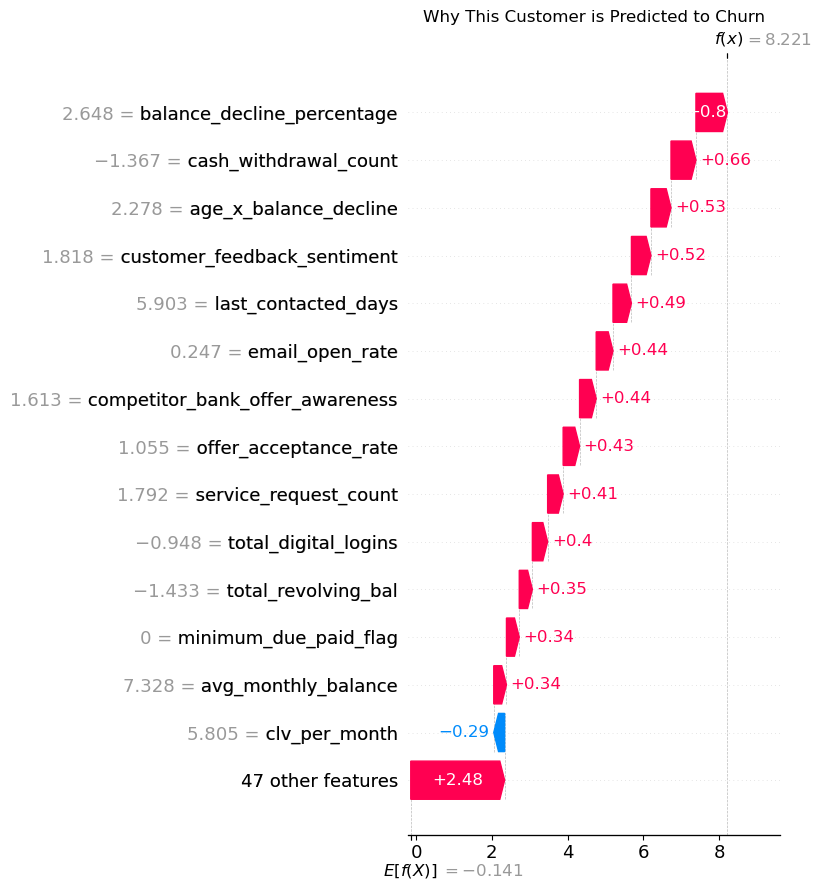

 Saved: shap_waterfall.png


In [26]:
top_churner_idx = catboost_val_probs.argmax()

shap.plots.waterfall(
    shap.Explanation(
        values        = shap_values[top_churner_idx],
        base_values   = explainer.expected_value,
        data          = X_val.iloc[top_churner_idx],
        feature_names = X_val.columns.tolist()
    ),
    max_display = 15,
    show        = False
)
plt.title('Why This Customer is Predicted to Churn')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: shap_waterfall.png")